# Handwritten Digit Classification Using Multilayer Perceptron (MLP)

This notebook details the end-to-end process of training a Neural Network to classify handwritten digits (0-9) using the MNIST dataset. Our goal is to achieve high accuracy while clearly documenting data preprocessing, model architecture, and comprehensive evaluation metrics.

## 1. Environment Setup & Imports

Below we import the tools necessary for data manipulation, plotting, model building, and evaluation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

## 2. Dataset Loading (MNIST)

We load the globally recognized MNIST dataset which contains 60,000 training images and 10,000 testing images of handwritten digits.

In [2]:
# Load dataset from Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training instances: {x_train.shape[0]} images, Shape: {x_train.shape[1:]}")
print(f"Testing instances:  {x_test.shape[0]} images, Shape: {x_test.shape[1:]}")

Training instances: 60000 images, Shape: (28, 28)
Testing instances:  10000 images, Shape: (28, 28)


## 3. Visualization of Sample Images

It is highly important to understand the organic nature of our data visually before passing it into a mathematical framework. Let's look at a few examples alongside their targets.

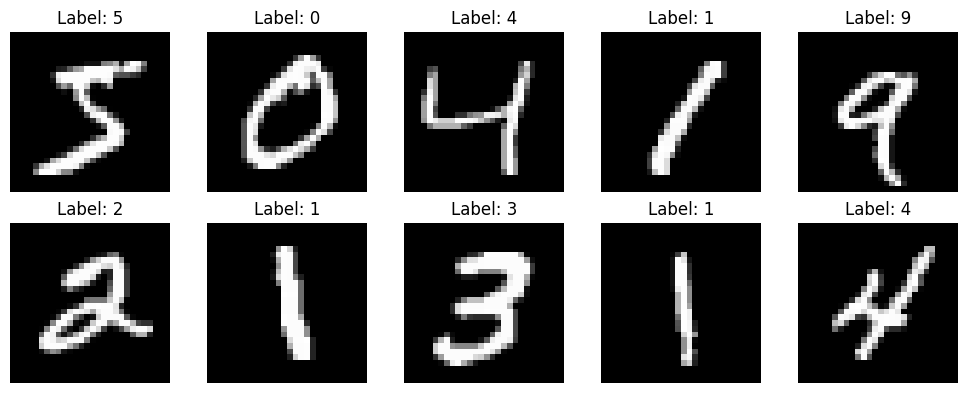

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing (Normalization)

Raw pixel values exist on a scale of `0` to `255`. To optimize Neural Network convergence, we normalize these bounds to fall strictly between `0.0` and `1.0`.

In [4]:
# Convert integers to float32 and normalize
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print(f"Max pixel value before: {np.max(x_train)}")
print(f"Max pixel value after:  {np.max(x_train_norm)}")

Max pixel value before: 255
Max pixel value after:  1.0


## 5. One-Hot Encoding

The model output uses a `softmax` activation to output probabilities for 10 distinct classes. Therefore, we convert integer labels (e.g. `2`) into categorical one-hot arrays (e.g. `[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]`).

In [5]:
num_classes = 10
y_train_encoded = keras.utils.to_categorical(y_train, num_classes)
y_test_encoded = keras.utils.to_categorical(y_test, num_classes)

print(f"Original label: {y_train[0]}")
print(f"Encoded vector: {y_train_encoded[0]}")

Original label: 5
Encoded vector: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 6. Model Building (Multilayer Perceptron)

We construct a sequentially layered Multi-Layer Perceptron (MLP).
- **Flatten Layer:** Restructures `28x28` into a `784` 1D array.
- **Hidden Layers:** Intermediary dense clusters implementing the `ReLU` non-linear activation.
- **Output Layer:** `10` neurons paired with `softmax` providing prediction confidence scores for each digit.

In [6]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28), name="Input_Flatten"),
    layers.Dense(128, activation='relu', name="Hidden_Layer_1"),
    layers.Dropout(0.2, name="Dropout_1"),
    layers.Dense(64, activation='relu', name="Hidden_Layer_2"),
    layers.Dropout(0.2, name="Dropout_2"),
    layers.Dense(num_classes, activation='softmax', name="Output_Layer")
])

model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

c:\Users\Parth\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Flatten (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Training Process

We train the model over 15 Epochs using batches of 128 instances. We utilize a `validation_split` to continuously measure generalizability against unseen samples during tracking.

In [7]:
batch_size = 128
epochs = 15

print("Initiating training phase...")
history = model.fit(
    x_train_norm, y_train_encoded, 
    batch_size=batch_size, 
    epochs=epochs, 
    validation_split=0.1,
    verbose=1
)
print("Training Complete!")

Initiating training phase...
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.4806 - val_accuracy: 0.9557 - val_loss: 0.1549
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9374 - loss: 0.2112 - val_accuracy: 0.9705 - val_loss: 0.1022
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9521 - loss: 0.1580 - val_accuracy: 0.9737 - val_loss: 0.0898
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9594 - loss: 0.1329 - val_accuracy: 0.9752 - val_loss: 0.0821
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9661 - loss: 0.1110 - val_accuracy: 0.9778 - val_loss: 0.0765
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9704 - loss: 0.0970 - val_accuracy: 0.9780 - val_loss: 0.0725
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.0876 - val_accuracy: 0.9798 - val_loss: 0.0721
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9758 - lo

## 8. Accuracy / Loss Graphs

Plotting historical Loss constraints helps us verify our model isn't under-fitting or heavily over-fitting the dataset.

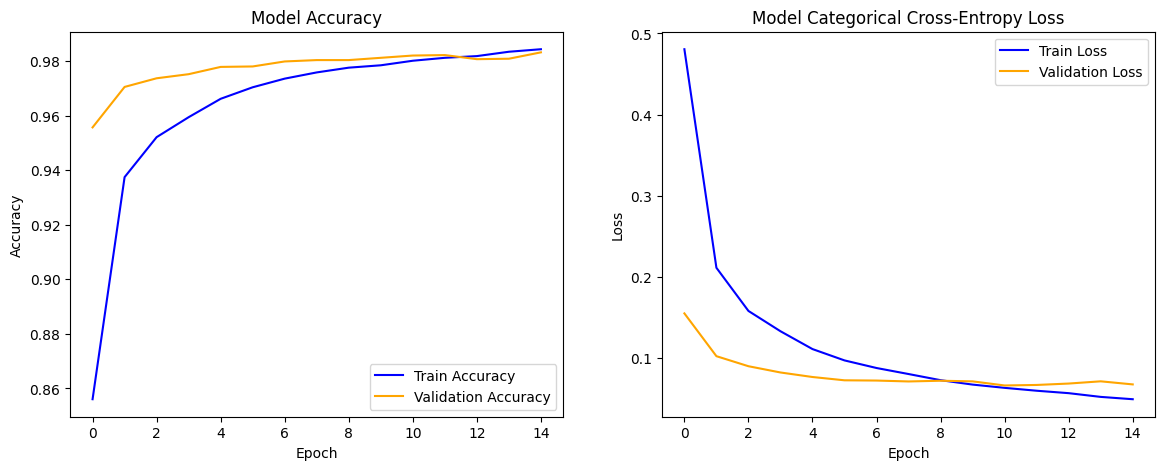

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Graph
ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='lower right')

# Loss Graph
ax[1].plot(history.history['loss'], label='Train Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax[1].set_title('Model Categorical Cross-Entropy Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='upper right')

plt.show()

## 9. Model Evaluation & Statistical Metrics

Finally, to conclusively prove the performance efficacy of our model, we run predictions on our sequestered *testing dataset* to determine precise diagnostic statistics:
- **Accuracy**: Total correct / Total Guesses.
- **Precision**: Total True Positives / Total Projected Positives.
- **Recall**: Total True Positives / Total Actual Positives.
- **F1-Score**: Harmonic Mean bridging Precision and Recall gaps.

In [9]:
# Derive probability distributions across test-set images
y_prob = model.predict(x_test_norm)
# Reduce probability vectors back down to integer class targets
y_pred = np.argmax(y_prob, axis=1)

# Scikit-Learn Metric Computations (using 'macro' averaging logic)
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("="*50)
print(f"TEST ACCURACY  : {acc * 100:.2f}%")
print(f"TEST PRECISION : {precision * 100:.2f}%")
print(f"TEST RECALL    : {recall * 100:.2f}%")
print(f"TEST F1 SCORE  : {f1 * 100:.2f}%")
print("="*50)

# Detailed Report By Digit Range
print("\nClassification Report by Integer Class:")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step
TEST ACCURACY  : 97.79%
TEST PRECISION : 97.76%
TEST RECALL    : 97.78%
TEST F1 SCORE  : 97.77%

Classification Report by Integer Class:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.97      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.96      0.98      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## 10. Save Weights for Frontend Infrastructure

Assuming our stats pass academic muster, we lock in our trained parameters for the external web application to utilize for real-time inference.

In [10]:
import os
model_dir = '../backend/model'
os.makedirs(model_dir, exist_ok=True)
model.save(f'{model_dir}/digit_model.h5')
print('Model successfully saved to ../backend/model/digit_model.h5')

Model successfully saved to ../backend/model/digit_model.h5
